# Proyecto Integrador: Diseño de Arquitectura Híbrida para Ecommify
**Universidad de la Sabana**

**Asignatura:** Diseño y Optimización de Bases de Datos

**Actividad:** Guía de Actividad Unidad 1

**Fecha:** Semana del 4 al 10 de Mayo  

---
### Integrantes del Equipo:
1. Juan Daniel Valderrama
2. Jorge Esteban Triviño Correa
3. Javier Andres Baron Fontanilla

## **Desarrollo Etapa 1**


### 1. Presentación del proyecto integrador

#### *Conexión a Google Drive y Carga de Datos*

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Conexión con Google Drive
drive.mount('/content/drive')

# Definir rutas de los archivos
base_path = '/content/drive/MyDrive/Bases_de_Datos_Documentos_Actividad_1/'

# Carga de datasets
df_sellers = pd.read_csv(base_path + 'olist_sellers_dataset.csv')
df_orders = pd.read_csv(base_path + 'olist_orders_dataset.csv')
df_customers = pd.read_csv(base_path + 'olist_customers_dataset.csv')
df_products = pd.read_csv(base_path + 'olist_products_dataset.csv')

df_geolocation = pd.read_csv(base_path + 'olist_geolocation_dataset.csv')
df_product_category_name = pd.read_csv(base_path + 'product_category_name_translation.csv')

df_order_reviews = pd.read_csv(base_path + 'olist_order_reviews_dataset.csv')
df_order_payments = pd.read_csv(base_path + 'olist_order_payments_dataset.csv')
df_order_items = pd.read_csv(base_path + 'olist_order_items_dataset.csv')

print("Dataset cargado exitosamente.")

Mounted at /content/drive
Dataset cargado exitosamente.



--- ENTIDAD: Customers ---
Columnas: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Nulos:
Series([], dtype: int64)
Duplicados en PK: 0

--- ENTIDAD: Orders ---
Columnas: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Nulos:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
Duplicados en PK: 0

--- ENTIDAD: Items ---
Columnas: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Nulos:
Series([], dtype: int64)
Duplicados en PK: 13984

--- ENTIDAD: Products ---
Columnas: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

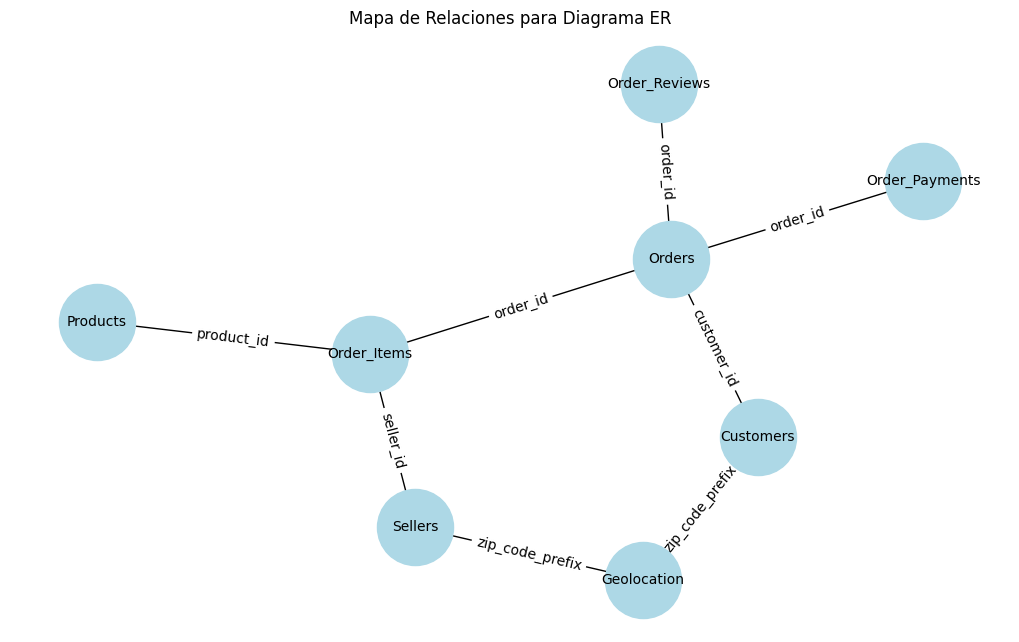

In [ ]:
# Inspección de Llaves y Relaciones
def info_er(df, name):
    print(f"\n--- ENTIDAD: {name} ---")
    print(f"Columnas: {df.columns.tolist()}")
    print(f"Nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"Duplicados en PK: {df.iloc[:,0].duplicated().sum()}")

datasets = {
    "Customers": df_customers, "Orders": df_orders,
    "Items": df_order_items, "Products": df_products,
    "Sellers": df_sellers, "Payments": df_order_payments,
    "Reviews": df_order_reviews
}

for name, df in datasets.items():
    info_er(df, name)

# Validación de Cardinalidad (Ejemplo: Pedidos por Cliente)
print("\n--- VALIDACIÓN DE CARDINALIDAD ---")
orders_per_customer = df_orders.groupby('customer_id').size().max()
print(f"Máximo de pedidos por customer_id (1:N): {orders_per_customer}")

# Visualización de la Red de Conexiones (Grafo de Tablas)
import networkx as nx

edges = [
    ("Customers", "Orders", "customer_id"),
    ("Orders", "Order_Items", "order_id"),
    ("Orders", "Order_Payments", "order_id"),
    ("Orders", "Order_Reviews", "order_id"),
    ("Products", "Order_Items", "product_id"),
    ("Sellers", "Order_Items", "seller_id"),
    ("Geolocation", "Customers", "zip_code_prefix"),
    ("Geolocation", "Sellers", "zip_code_prefix")
]

G = nx.Graph()
for u, v, label in edges:
    G.add_edge(u, v, label=label)

plt.figure(figsize=(10,6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=3000, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['label'] for u, v, d in G.edges(data=True)})
plt.title("Mapa de Relaciones para Diagrama ER")
plt.show()

#### *Revisar estructura, calidad de los datos y valores nulos*

In [ ]:
# Diccionario para organizar todos los DataSets
datasets = {
    "Sellers": df_sellers,
    "Orders": df_orders,
    "Customers": df_customers,
    "Products": df_products,
    "Geolocation": df_geolocation,
    "Category_Translation": df_product_category_name,
    "Reviews": df_order_reviews,
    "Payments": df_order_payments,
    "Order_Items": df_order_items
}

# Bucle para revisión de estructura y nulos
for name, df in datasets.items():
    print(f"--- Análisis de: {name} ---")
    print(f"Dimensiones: {df.shape}")
    print(f"Valores Nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}\n") # Solo muestra columnas con nulos
    # df.info() se puede ver aquí, pero es mejor usar .dtypes para muchos datos
    print(f"Tipos de Datos:\n{df.dtypes}\n")
    print("-" * 30)

--- Análisis de: Sellers ---
Dimensiones: (3095, 4)
Valores Nulos:
Series([], dtype: int64)

Tipos de Datos:
seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object

------------------------------
--- Análisis de: Orders ---
Dimensiones: (99441, 8)
Valores Nulos:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Tipos de Datos:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

------------------------------
--- Análisis de: Customers ---
Dimensiones: (99441, 5)
Valores Nulos:
Series([], dtype: int64)

Tipos de Datos:
customer_id             

#### *Identificar relaciones entre tablas*

In [ ]:
import pandas as pd

# Lista de nombres de tus datasets y sus dataframes
df_list = {
    'Sellers': df_sellers, 'Orders': df_orders, 'Customers': df_customers,
    'Products': df_products, 'Geolocation': df_geolocation, 'Reviews': df_order_reviews,
    'Payments': df_order_payments, 'Order_Items': df_order_items
}

relationships = []

# Comparar columnas entre todos los pares de tablas
table_names = list(df_list.keys())
for i in range(len(table_names)):
    for j in range(i + 1, len(table_names)):
        t1, t2 = table_names[i], table_names[j]
        common_cols = set(df_list[t1].columns) & set(df_list[t2].columns)

        for col in common_cols:
            # Filtrar columnas que suelen ser llaves (que terminan en _id, _zip_code, etc.)
            if '_id' in col or '_code' in col or 'product_category_name' in col:
                relationships.append({'Tabla A': t1, 'Tabla B': t2, 'Llave Común': col})

# Mostrar el mapa de relaciones detectado
df_rel = pd.DataFrame(relationships)
print("Relaciones Detectadas Automáticamente:")
display(df_rel)

Relaciones Detectadas Automáticamente:


,Tabla A,Tabla B,Llave Común
0,Sellers,Order_Items,seller_id
1,Orders,Customers,customer_id
2,Orders,Reviews,order_id
3,Orders,Payments,order_id
4,Orders,Order_Items,order_id
5,Products,Order_Items,product_id
6,Reviews,Payments,order_id
7,Reviews,Order_Items,order_id
8,Payments,Order_Items,order_id


#### *Visualizar distribuciones temporales y geográficas*

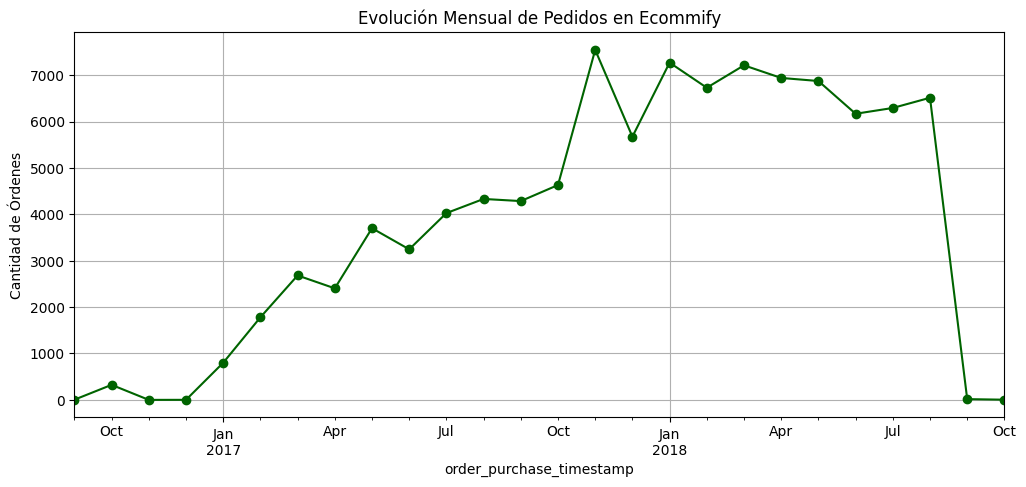

In [ ]:
# Convertir a formato fecha
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

# Visualización de ventas en el tiempo
plt.figure(figsize=(12, 5))
df_orders.set_index('order_purchase_timestamp').resample('ME').size().plot(kind='line', marker='o', color='darkgreen')
plt.title('Evolución Mensual de Pedidos en Ecommify')
plt.ylabel('Cantidad de Órdenes')
plt.grid(True)
plt.show()

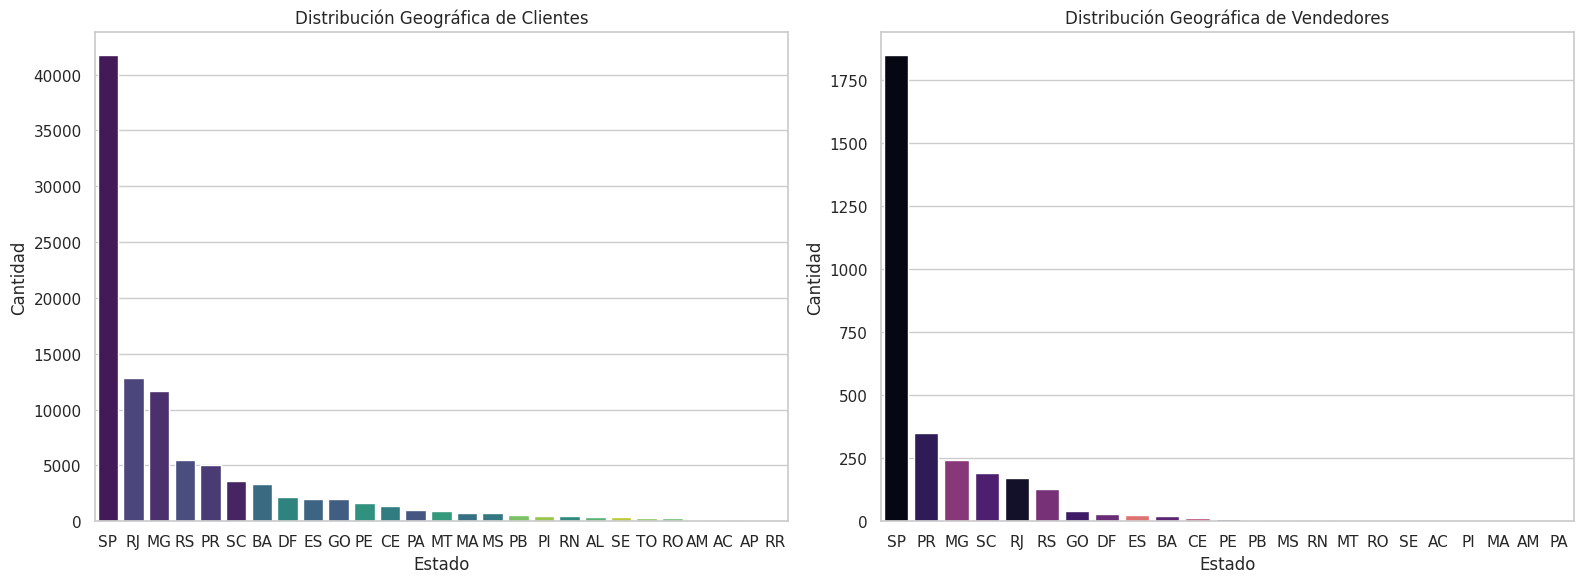

In [ ]:
# Configuración de estilo
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución de Clientes por Estado
sns.countplot(
    data=df_customers,
    x='customer_state',
    hue='customer_state',
    ax=axes[0],
    palette='viridis',
    order=df_customers['customer_state'].value_counts().index,
    legend=False
)
axes[0].set_title('Distribución Geográfica de Clientes')
axes[0].set_xlabel('Estado')
axes[0].set_ylabel('Cantidad')

# Distribución de Vendedores por Estado
sns.countplot(
    data=df_sellers,
    x='seller_state',
    hue='seller_state',
    ax=axes[1],
    palette='magma',
    order=df_sellers['seller_state'].value_counts().index,
    legend=False
)
axes[1].set_title('Distribución Geográfica de Vendedores')
axes[1].set_xlabel('Estado')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()


### 2.  Formación de equipos y asignación de enfoques arquitectónicos

#### *Seleccionar enfoque prioritario con justificación*

El equipo decide seleccionar la Arquitectura Políglota Híbrida
La solución propuesta es entonces híbrida basada en el Teorema CAP, buscando un

---

balance entre consistencia y disponibilidad. Justificación de la Arquitectura:

**PostgreSQL:** Principal almacenamiento para transacciones donde la integridad esta en primer plano, como pagos y estados de envío.

**MongoDB:** Almacenamiento de documentos para el catálogo, permitiendo que diferentes categorías de productos tengan atributos variables sin modificar el esquema global.



### 3. Definición del alcance específico del proyecto

**Formular 5 preguntas de investigación específicas relacionadas con su enfoque
arquitectónico**


- ¿Cuál es la diferencia en el tiempo de respuesta al consultar un catálogo de productos con atributos variables en MongoDB frente a una estructura de tablas relacionales en PostgreSQL?
- ¿Cómo impacta la latencia del sistema al realizar una transacción de compra que requiere validar stock en PostgreSQL y actualizar simultáneamente logs de actividad en MongoDB?
- ¿De qué manera la naturaleza schema-less de MongoDB facilita la integración de nuevas categorías de productos tecnológicos sin interrumpir la disponibilidad de la plataforma Ecommify?
- ¿Cómo afecta la duplicación de datos (desnormalización) necesaria en MongoDB al costo total de almacenamiento en comparación con el modelo normalizado de PostgreSQL?
- ¿Cuál es el mecanismo más eficiente para sincronizar datos críticos entre PostgreSQL y MongoDB para asegurar que los reportes de ventas reflejen información del catálogo en tiempo real?


**Definir al menos 4 métricas de éxito cuantificables**:

- Latencia de Consulta de Producto: Lograr un tiempo de respuesta promedio inferior a 200 ms en la recuperación de detalles de producto desde MongoDB.
- Carga Transaccional: Soportar un flujo de 500 transacciones concurrentes por segundo en PostgreSQL sin pérdida de integridad de datos.
- Disponibilidad del Sistema: Mantener un uptime del 99.9% durante las pruebas de integración de ambas bases de datos.
- Eficiencia de Sincronización: Asegurar que la latencia de replicación o actualización de estados entre bases de datos no supere los 2 segundos.

**Establecer limitaciones técnicas de plataformas gratuitas**:

- Supabase - PostgreSQL
  - Almacenamiento de base de datos: Limitado a 500MB en el plan gratuito.
  - Conexiones simultáneas: Máximo 60 conexiones directas, puede ser un cuello de botella en pruebas de carga.
  - Pausa por inactividad: El proyecto entra en modo "pausa" tras una semana sin actividad, requiriendo reactivación manual.
  
- MongoDB Atlas M0 - Sandbox
  - Almacenamiento: Solo 512MB a 5GB , dependiendo de la región, lo cual es poco para logs extensos.
  - Operaciones: No permite la creación de índices de búsqueda avanzada (Atlas Search) en todas sus capacidades.
  - Rendimiento: CPU compartida; no hay garantías de IOPS, lo que puede generar latencia variable.

- Google Colab
  - Persistencia: El entorno de ejecución es efímero; si la sesión se cierra, los datos locales o instalaciones de drivers se borran.
  - Memoria RAM: Limitada a aproximadamente 12GB; procesos pesados de limpieza de datos de Olist podrían causar que el kernel se reinicie.
  - Tiempo de ejecución: Límite de 12 horas continuas por sesión.